# **TFM Project - Machine Learning for Drug Discovery in Neurodegenerative Diseases**
# **[Part 5] Compare and evaluate ML Supervised Models**

Carla D. Di Monno

In **Part 5**, a comparison of machine learning models for drug discovery aimed at treating neurodegenerative diseases is conducted. Various classification and regression algorithms are evaluated to predict the bioactivity values.

---

## **Installing libraries**

In [1]:
! pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.8 MB/s eta 0:00:00


## **Importing libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lazypredict
import io
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef
from lazypredict.Supervised import LazyClassifier, LazyRegressor

from google.colab import files

In [3]:
def upload_files (index_fields=None):
  uploaded = files.upload()
  for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), index_col = index_fields)
    return df, fn

## **Load the dataset**

In [4]:
# Upload dataset ({target}_bioactivity_data_Pubchem-fp_wo_filtered.csv)
df, uploaded_filename = upload_files()
print(df.shape)
df.head()

Saving LRRK2_G2019S_bioactivity_data_Pubchem-fp_wo_filtered.csv to LRRK2_G2019S_bioactivity_data_Pubchem-fp_wo_filtered.csv
User uploaded file "LRRK2_G2019S_bioactivity_data_Pubchem-fp_wo_filtered.csv" with length 1692905 bytes
(1654, 508)


,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP12,PubchemFP13,PubchemFP15,PubchemFP16,PubchemFP17,PubchemFP18,PubchemFP19,...,PubchemFP833,PubchemFP834,PubchemFP840,PubchemFP842,PubchemFP860,PubchemFP861,PubchemFP863,PubchemFP868,bioactivity_class,pchembl_value
0,1,0,0,1,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,4.88000
1,1,0,0,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,5.39000
2,1,1,0,1,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,1,7.58875
3,1,1,0,1,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,5.60000
4,1,1,0,1,0,1,1,0,1,1,...,0,0,0,0,0,0,0,0,1,6.69000


In [5]:
target_name=uploaded_filename.replace('_bioactivity_data_Pubchem-fp_wo_filtered.csv', '')

In [6]:
X = df.drop(['bioactivity_class','pchembl_value'], axis=1)
Y = df['pchembl_value'] #reg
Z = df['bioactivity_class'] #class

## **Data pre-processing**

### **Examine X dimensions**

In [7]:
X.shape

(1654, 506)

### **Remove low variance features**

In [8]:
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)

In [9]:
X.shape

(1654, 115)

### **Data split (80/20 ratio)**

In [10]:
X_train, X_test, Z_train, Z_test = train_test_split(X, Z, test_size=0.2, random_state=42) #class
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) #reg

print(f"Train: {X_train.shape[0]} records")
print(f"Test: {X_test.shape[0]} records")

Train: 1323 records
Test: 331 records


## **Compare ML algorithms**

## **Classification**

### **Define and builds the lazyclassifier**


In [11]:
lazyC = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=matthews_corrcoef)
modelsC, predictionsC = lazyC.fit(X_train, X_test, Z_train, Z_test)

In [15]:
print(modelsC.columns)

Index(['Accuracy', 'Balanced Accuracy', 'ROC AUC', 'F1 Score', 'Precision',
       'Recall', 'matthews_corrcoef', 'Time Taken'],
      dtype='object')


### **Filtered Classification Models (MCC >= 0.40)**

In [18]:
top_modelsC = modelsC[modelsC['matthews_corrcoef'] >= 0.40]
top_modelsC = top_modelsC.sort_values(by="matthews_corrcoef", ascending=False)

### **Values for the `top_modelsC` DataFrame**

In [19]:
display(top_modelsC[['matthews_corrcoef','ROC AUC','Time Taken']])

,matthews_corrcoef,ROC AUC,Time Taken
Model,,,
LinearDiscriminantAnalysis,0.523857,0.826237,0.106945
PassiveAggressiveClassifier,0.517371,0.849785,0.049208
DecisionTreeClassifier,0.509917,0.754409,0.057179
XGBClassifier,0.471643,0.910914,0.225747
LGBMClassifier,0.428501,0.918280,0.252051
LinearSVC,0.422059,0.854516,0.125452


In [20]:
top_modelsC[['matthews_corrcoef','ROC AUC','Accuracy','F1 Score', 'Time Taken']].to_csv(f'{target_name}_top_models_classifier_performance.csv', index=True)

## **Regression**

### **Define and builds the lazyregressor**

In [30]:
lazyR = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
modelsR, predictionsR = lazyR.fit(X_train, X_test, Y_train, Y_test)

In [31]:
print(modelsR.columns)

Index(['Adjusted R-Squared', 'R-Squared', 'RMSE', 'Time Taken'], dtype='object')


### **Filtered Regression Models (R-Squared >= 0.50)**

In [33]:
top_modelsR = modelsR[modelsR['R-Squared'] >= 0.50]
top_modelsR = top_modelsR.sort_values(by="R-Squared", ascending=False)

### **Values for the `top_modelsR` DataFrame**

In [34]:
display(top_modelsR[['R-Squared', 'RMSE', 'Time Taken']])

,R-Squared,RMSE,Time Taken
Model,,,
RandomForestRegressor,0.602432,0.679783,2.057733
HistGradientBoostingRegressor,0.601843,0.680286,0.715375
GradientBoostingRegressor,0.595051,0.686064,0.569818
NuSVR,0.593526,0.687355,0.235574
BaggingRegressor,0.592470,0.688247,0.205095
SVR,0.589628,0.690643,0.350189
XGBRegressor,0.584783,0.694707,0.391904
LGBMRegressor,0.568612,0.708106,0.230345
KNeighborsRegressor,0.541496,0.730022,0.036627


In [35]:
top_modelsR[['R-Squared', 'RMSE', 'Time Taken']].to_csv(f'{target_name}_top_models_regressor_performance.csv', index=True)

## **Data visualization of model performance: Bar plot**

### **Comparison of Top 3 Classification Models**

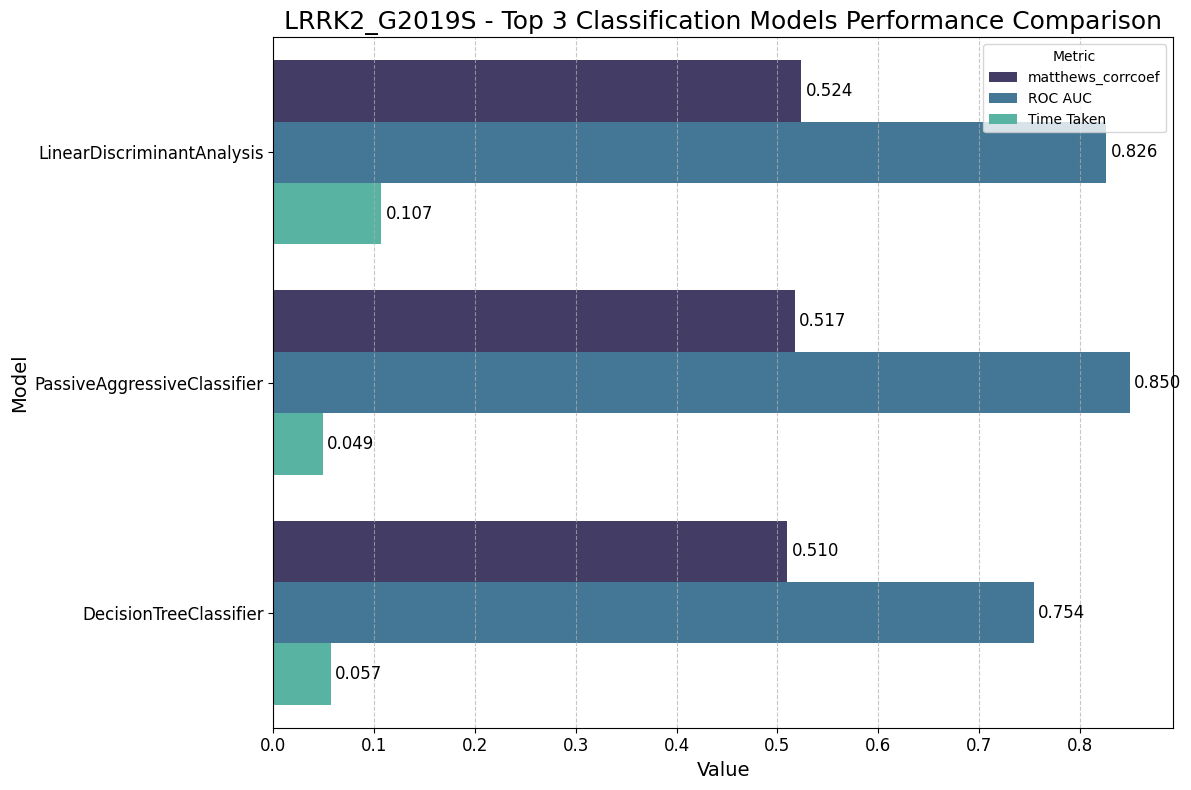

In [29]:
top_3_C = top_modelsC.head(3)

# Melt the DataFrame for easier plotting of multiple metrics per model
top_3_C_melted = top_3_C[['matthews_corrcoef', 'ROC AUC', 'Time Taken']].reset_index().melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Value', y='Model', hue='Metric', data=top_3_C_melted, palette='mako')
plt.title(f'{target_name} - Top 3 Classification Models Performance Comparison', fontsize=18)
plt.xlabel('Value', fontsize=14)
plt.ylabel('Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for container in ax.containers:
    labels = []
    metric_name = container.get_label()
    for rect in container.get_children():
        value = rect.get_width()
        labels.append(f'{value:.3f}')
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=12, padding=3)

plt.legend(title='Metric')
plt.tight_layout()
plt.savefig(f'{target_name}_Classification_Models_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### **Comparison of Top 3 Regression Models**

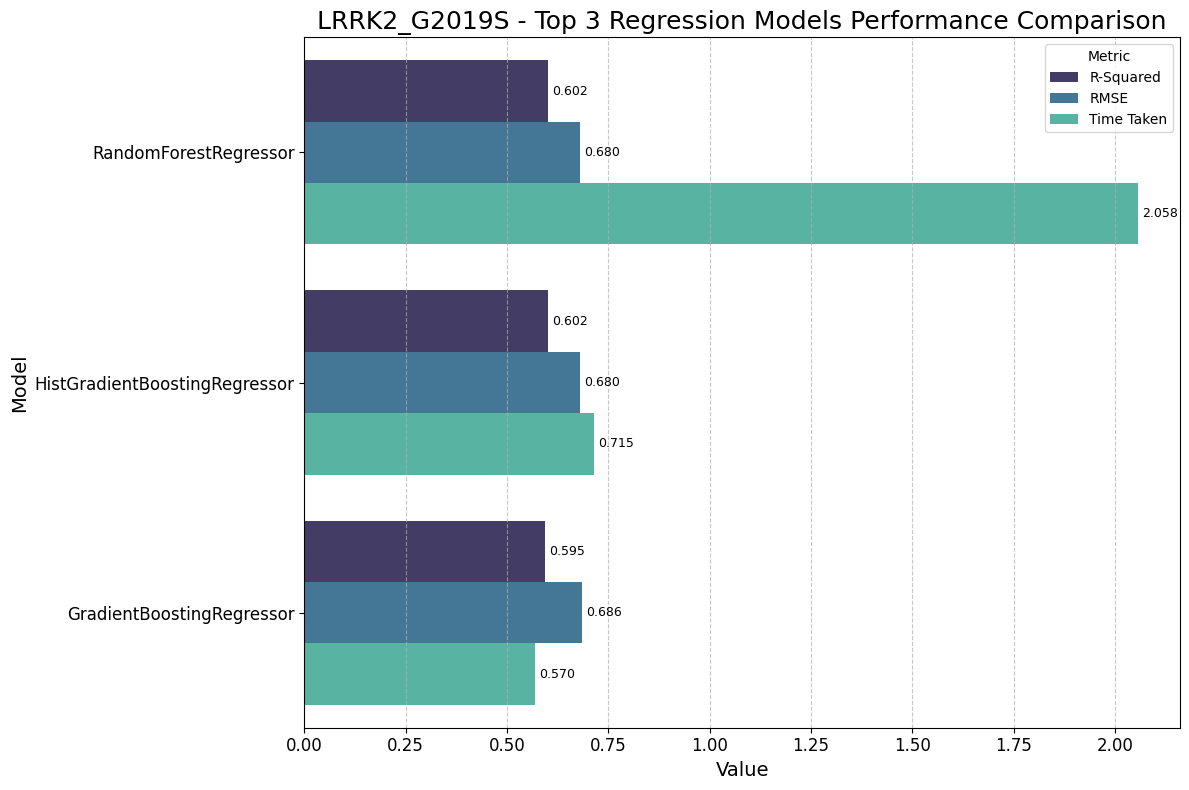

In [39]:
top_3_R = top_modelsR.head(3)

top_3_R_melted = top_3_R[['R-Squared', 'RMSE', 'Time Taken']].reset_index().melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Value', y='Model', hue='Metric', data=top_3_R_melted, palette='mako')
plt.title(f'{target_name} - Top 3 Regression Models Performance Comparison', fontsize=18)
plt.xlabel('Value', fontsize=14)
plt.ylabel('Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for container in ax.containers:
    labels = []
    metric_name = container.get_label()
    for rect in container.get_children():
        value = rect.get_width()
        labels.append(f'{value:.3f}')
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=9, padding=3)

plt.legend(title='Metric')
plt.tight_layout()
plt.savefig(f'{target_name}_Regression_Models_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---